limitation : the factual knowledge of tutor utterances are not checked 

In [7]:
import pandas as pd
import numpy as np
import json
from pprint import pprint

In [8]:
# Bridge 2stage 991 contexts / 12 per batch / 6 different models / total 12 * 6 * 991 = 71,352 responses 
all_results_df = pd.read_csv('data_preference_train_only/bridge_2tage__with_reference_solution_more_models/preference_score__all_results_df.csv')
response_pairs_df = pd.read_csv('data_preference_train_only/bridge_2tage__with_reference_solution_more_models/response_pairs_df.csv')

In [9]:
# npmi_table = pd.read_csv('data_pmi_table/npmi_table.csv', index_col=0) 
ppmi_table = pd.read_csv('data_pmi_table/ppmi_table.csv', index_col=0) 
contingency_table = pd.read_csv('data_pmi_table/contingency_table.csv', index_col=0) 

In [10]:
all_results_df.head(1)

,context_data_idx,generation_round,problem,topic,student_mistake,error_category,predicted_pedagogy,predicted_category_prob,predicted_category_prob_list,prompt,model,response,score,response_word_count,strategy,intention
0,0,0,milly is making feather boas for her dance tea...,Math Word Problem,"'milly can only take 25 of 20 tail feathers, w...",reached_correct_solution_but_proceeded_further,focus,0.62298,"[{'label': 'focus', 'probability': 0.62298}, {...",System: \nYou are an experienced elementary ma...,gemini-3.5-flash-lite,you figured out the total number of feathers m...,0.253611,59,provide a minor correction,"explain the student's mistake (e.g., what is w..."


In [11]:
response_pairs_df

,context_data_idx,error_category,problem,topic,student_mistake,prompt,chosen_model,chosen_response,chosen_response_word_count,chosen_score,...,rejected_response_word_count,rejected_score,rejected_label,rejected_label_prob,rejected_label_prob_list,score_difference,strategy,intention,max_ppmi,normalized_score_difference
0,0,reached_correct_solution_but_proceeded_further,milly is making feather boas for her dance tea...,Math Word Problem,"'milly can only take 25 of 20 tail feathers, w...",System: \nYou are an experienced elementary ma...,llama3.2:3b,the student is correct in calculating the tota...,79,0.260977,...,15,0.020906,telling,0.895279,"[{'label': 'telling', 'probability': 0.895279}...",0.240071,provide a minor correction,"explain the student's mistake (e.g., what is w...",0.267413,0.897755
1,0,reached_correct_solution_but_proceeded_further,milly is making feather boas for her dance tea...,Math Word Problem,"'milly can only take 25 of 20 tail feathers, w...",System: \nYou are an experienced elementary ma...,gemini-3.5-flash-lite,"you correctly figured out that milly needs 2,4...",54,0.260899,...,18,0.118706,telling,0.462403,"[{'label': 'telling', 'probability': 0.462403}...",0.142193,provide a minor correction,"explain the student's mistake (e.g., what is w...",0.267413,0.531735
2,0,reached_correct_solution_but_proceeded_further,milly is making feather boas for her dance tea...,Math Word Problem,"'milly can only take 25 of 20 tail feathers, w...",System: \nYou are an experienced elementary ma...,llama3.1-8b,let's take a closer look at the student's work...,47,0.260737,...,35,0.145494,telling,0.435358,"[{'label': 'telling', 'probability': 0.435358}...",0.115243,provide a minor correction,"explain the student's mistake (e.g., what is w...",0.267413,0.430955
3,0,reached_correct_solution_but_proceeded_further,milly is making feather boas for her dance tea...,Math Word Problem,"'milly can only take 25 of 20 tail feathers, w...",System: \nYou are an experienced elementary ma...,llama3.2:3b,let's take a look at where the student went wr...,49,0.260543,...,26,0.146273,probing,0.538833,"[{'label': 'probing', 'probability': 0.538833}...",0.114270,provide a minor correction,"explain the student's mistake (e.g., what is w...",0.267413,0.427318
4,0,reached_correct_solution_but_proceeded_further,milly is making feather boas for her dance tea...,Math Word Problem,"'milly can only take 25 of 20 tail feathers, w...",System: \nYou are an experienced elementary ma...,llama3.1-8b,let's look at the mistake: the student is mult...,69,0.260469,...,40,0.190328,focus,0.648217,"[{'label': 'focus', 'probability': 0.648217}, ...",0.070142,provide a minor correction,"explain the student's mistake (e.g., what is w...",0.267413,0.262297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24293,692,none_of_the_above,"before marcus went on a road trip to la, his c...",Math Word Problem,"'on the first fill-up, marcus used 20 x 30 600...",System: \nYou are an experienced elementary ma...,llama3.1-8b,let's take a closer look at the first fill-up....,45,0.256802,...,67,0.250192,focus,0.841799,"[{'label': 'focus', 'probability': 0.841799}, ...",0.006610,provide a minor correction,correct the student's mistake,0.297160,0.022245
24294,692,none_of_the_above,"before marcus went on a road trip to la, his c...",Math Word Problem,"'on the first fill-up, marcus used 20 x 30 600...",System: \nYou are an experienced elementary ma...,mistral-nemo:12b,it's great that you calculated the miles used ...,62,0.256220,...,29,0.250517,focus,0.842755,"[{'label': 'focus', 'probability': 0.842755}, ...",0.005703,provide a minor correction,correct the student's mistake,0.297160,0.019192
24295,692,none_of_the_above,"before marcus went on a road trip to la, his c...",Math Word Problem,"'on the first fill-up, marcus used 20 x 30 600...",System: \nYou are an experienced elementary ma...,llama3.2:3b,let's review the mistake together! the student...,56,

---
## 0. Anomaly Check ( Response Length )

In [12]:
##################################################
# Chosen Response Length
##################################################
print('Counting the number of chosen_response_word_count values in intervals of 50')
bins = range(0, response_pairs_df['chosen_response_word_count'].max() + 50, 50)
bin_counts = pd.cut(response_pairs_df['chosen_response_word_count'], bins, right=False).value_counts().sort_index()
print(bin_counts)

print('-' * 100)

print('chosen_response_word_count statistics')
desc = response_pairs_df['chosen_response_word_count'].describe(percentiles=[.25, .5, .75, .9, .99, .999])
desc = desc.rename({
    '25%': '25%',
    '50%': '50%',
    '75%': '75%',
    '90%': '90%',
    '99%': '99%',
    '99.9%': '99.9%' if '99.9%' in desc else '99.9%'
})
print(desc)


print('-' * 100)

print('chosen_response_word_count statistics by chosen_model')
chosen_stats = response_pairs_df.groupby('chosen_model')['chosen_response_word_count'].agg(['mean', 'min', 'max', 'median']).sort_values('max', ascending=False)
print(chosen_stats)

print('-' * 100)

print('chosen_response_word_count statistics by error_category')
chosen_stats = response_pairs_df.groupby('error_category')['chosen_response_word_count'].agg(['mean', 'min', 'max', 'median']).sort_values('max', ascending=False)
print(chosen_stats)

print('-' * 100)

print('chosen_response_word_count statistics by intention')
chosen_stats = response_pairs_df.groupby('intention')['chosen_response_word_count'].agg(['mean', 'min', 'max', 'median']).sort_values('max', ascending=False)
print(chosen_stats)

print('-' * 100)

print('chosen_response_word_count statistics by strategy')
chosen_stats = response_pairs_df.groupby('strategy')['chosen_response_word_count'].agg(['mean', 'min', 'max', 'median']).sort_values('max', ascending=False)
print(chosen_stats)

Counting the number of chosen_response_word_count values in intervals of 50
chosen_response_word_count
[0, 50)       13722
[50, 100)     10142
[100, 150)      395
[150, 200)       32
[200, 250)        3
[250, 300)        2
[300, 350)        0
[350, 400)        1
[400, 450)        1
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
chosen_response_word_count statistics
count    24298.000000
mean        49.495020
std         19.700856
min          7.000000
25%         37.000000
50%         47.000000
75%         60.000000
90%         74.000000
99%        108.000000
99.9%      157.703000
max        417.000000
Name: chosen_response_word_count, dtype: float64
----------------------------------------------------------------------------------------------------
chosen_response_word_count statistics by chosen_model
                            mean  min  max  median
chosen_model                                      
llam

In [13]:
for i, row in response_pairs_df[response_pairs_df['chosen_response_word_count'] >= 500][['chosen_response', 'chosen_response_word_count', 'chosen_model', 'chosen_label', 'error_category', 'chosen_label_prob_list']].sort_values(by='chosen_response_word_count', ascending=False).iterrows():
    print('index     : ', i)
    print('response  : ', row['chosen_response'])
    print('word_count: ', row['chosen_response_word_count'])
    print('model     : ', row['chosen_model'])
    print('label     : ', row['chosen_label'])
    print('error_category: ', row['error_category'])
    print('label_prob: ', row['chosen_label_prob_list'])
    

In [14]:
for i in response_pairs_df[response_pairs_df['chosen_response_word_count'] < 10][['chosen_response', 'chosen_response_word_count', 'chosen_model', 'chosen_label', 'chosen_label_prob_list', 'error_category']].sort_values(by='chosen_response_word_count', ascending=False).index:
    print('index     : ', i)
    print('response  : ', response_pairs_df.loc[i, 'chosen_response'])
    print('word_count: ', response_pairs_df.loc[i, 'chosen_response_word_count'])
    print('model     : ', response_pairs_df.loc[i, 'chosen_model'])
    print('label     : ', response_pairs_df.loc[i, 'chosen_label'])
    print('error_category: ', response_pairs_df.loc[i, 'error_category'])
    print('label_prob: ', response_pairs_df.loc[i, 'chosen_label_prob_list'])
    print('-' * 100)

index     :  4166
response  :  "did you notice something unusual about the weekend calculation?
word_count:  9
model     :  mistral-nemo:12b
label     :  probing
error_category:  misunderstanding_of_a_question
label_prob:  [{'label': 'probing', 'probability': 0.568663}, {'label': 'focus', 'probability': 0.418503}, {'label': 'telling', 'probability': 0.006511}, {'label': 'generic', 'probability': 0.006323}]
----------------------------------------------------------------------------------------------------
index     :  5579
response  :  "what happened to the $80 his mother gave him?"
word_count:  9
model     :  mistral-nemo:12b
label     :  probing
error_category:  unit_conversion_error
label_prob:  [{'label': 'probing', 'probability': 0.888279}, {'label': 'focus', 'probability': 0.102222}, {'label': 'telling', 'probability': 0.005391}, {'label': 'generic', 'probability': 0.004108}]
----------------------------------------------------------------------------------------------------
inde

In [15]:
##################################################
# Rejected Response Length
##################################################

print('Counting the number of rejected_response_word_count values in intervals of 50')
bins = range(0, response_pairs_df['rejected_response_word_count'].max() + 50, 50)
bin_counts = pd.cut(response_pairs_df['rejected_response_word_count'], bins, right=False).value_counts().sort_index()
print(bin_counts)

print('-' * 100)

print('rejected_response_word_count statistics')
desc = response_pairs_df['rejected_response_word_count'].describe(percentiles=[.25, .5, .75, .9, .99, .999])
desc = desc.rename({
    '25%': '25%',
    '50%': '50%',
    '75%': '75%',
    '90%': '90%',
    '99%': '99%',
    '99.9%': '99.9%' if '99.9%' in desc else '99.9%'
})
print(desc)

print('-' * 100)

print('rejected_response_word_count statistics by rejected_model')
rejected_stats = response_pairs_df.groupby('rejected_model')['rejected_response_word_count'].agg(['mean', 'min', 'max', 'median']).sort_values('max', ascending=False)
print(rejected_stats)

print('-' * 100)

print('rejected_response_word_count statistics by error_category')
rejected_stats = response_pairs_df.groupby('error_category')['rejected_response_word_count'].agg(['mean', 'min', 'max', 'median']).sort_values('max', ascending=False)
print(rejected_stats)

print('-' * 100)

print('rejected_response_word_count statistics by intention')
rejected_stats = response_pairs_df.groupby('intention')['rejected_response_word_count'].agg(['mean', 'min', 'max', 'median']).sort_values('max', ascending=False)
print(rejected_stats)

print('-' * 100)

print('rejected_response_word_count statistics by strategy')
rejected_stats = response_pairs_df.groupby('strategy')['rejected_response_word_count'].agg(['mean', 'min', 'max', 'median']).sort_values('max', ascending=False)
print(rejected_stats)

Counting the number of rejected_response_word_count values in intervals of 50
rejected_response_word_count
[0, 50)       14049
[50, 100)      9945
[100, 150)      285
[150, 200)       13
[200, 250)        5
[250, 300)        1
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
rejected_response_word_count statistics
count    24298.000000
mean        48.887810
std         17.943723
min          7.000000
25%         37.000000
50%         46.000000
75%         58.000000
90%         72.000000
99%        102.000000
99.9%      141.000000
max        263.000000
Name: rejected_response_word_count, dtype: float64
----------------------------------------------------------------------------------------------------
rejected_response_word_count statistics by rejected_model
                            mean  min  max  median
rejected_model                                    
llama3.2:1b            64.379096   13  263    62.0
l

In [16]:


for i in response_pairs_df[response_pairs_df['rejected_response_word_count'] > 500][['rejected_response', 'rejected_response_word_count', 'rejected_model', 'rejected_label', 'error_category', 'rejected_label_prob_list']].sort_values(by='rejected_response_word_count', ascending=False).index:
    print('index     : ', i)
    print('response  : ', response_pairs_df.loc[i, 'rejected_response'])
    print('word_count: ', response_pairs_df.loc[i, 'rejected_response_word_count'])
    print('model     : ', response_pairs_df.loc[i, 'rejected_model'])
    print('label     : ', response_pairs_df.loc[i, 'rejected_label'])
    print('error_category: ', response_pairs_df.loc[i, 'error_category'])
    print('label_prob: ', response_pairs_df.loc[i, 'rejected_label_prob_list'])
    print('-' * 100)

In [17]:
for i in response_pairs_df[response_pairs_df['rejected_response_word_count'] < 5][['rejected_response', 'rejected_response_word_count', 'rejected_model', 'rejected_label', 'error_category', 'rejected_label_prob_list']].sort_values(by='rejected_response_word_count', ascending=False).index:
    print('index     : ', i)
    print('response  : ', response_pairs_df.loc[i, 'rejected_response'])
    print('word_count: ', response_pairs_df.loc[i, 'rejected_response_word_count'])
    print('model     : ', response_pairs_df.loc[i, 'rejected_model'])
    print('label     : ', response_pairs_df.loc[i, 'rejected_label'])
    print('error_category: ', response_pairs_df.loc[i, 'error_category'])
    print('label_prob: ', response_pairs_df.loc[i, 'rejected_label_prob_list'])
    print('-' * 100)

In [18]:
##################################################
# Anomaly removal is disabled
##################################################
# Keep all response pairs; uncomment these lines only if anomaly removal is needed.
# max_word_count = response_pairs_df['chosen_response_word_count'].max()
# response_pairs_df = response_pairs_df[response_pairs_df['chosen_response_word_count'] != max_word_count]

print('chosen_response_word_count statistics (anomaly retained)')
desc = response_pairs_df['chosen_response_word_count'].describe(percentiles=[.25, .5, .75, .9, .99, .999])
desc = desc.rename({
    '25%': '25%',
    '50%': '50%',
    '75%': '75%',
    '90%': '90%',
    '99%': '99%',
    '99.9%': '99.9%' if '99.9%' in desc else '99.9%'
})
print(desc)

print('-' * 100)

print('chosen_response_word_count statistics by chosen_model (anomaly retained)')
chosen_stats = response_pairs_df.groupby('chosen_model')['chosen_response_word_count'].agg(['mean', 'min', 'max', 'median']).sort_values('max', ascending=False)
print(chosen_stats)

print('-' * 100)

print('chosen_response_word_count statistics by error_category (anomaly retained)')
chosen_stats = response_pairs_df.groupby('error_category')['chosen_response_word_count'].agg(['mean', 'min', 'max', 'median']).sort_values('max', ascending=False)
print(chosen_stats)

print('-' * 100)

print('chosen_response_word_count statistics by intention (anomaly retained)')
chosen_stats = response_pairs_df.groupby('intention')['chosen_response_word_count'].agg(['mean', 'min', 'max', 'median']).sort_values('max', ascending=False)
print(chosen_stats)

print('-' * 100)

print('chosen_response_word_count statistics by strategy (anomaly retained)')
chosen_stats = response_pairs_df.groupby('strategy')['chosen_response_word_count'].agg(['mean', 'min', 'max', 'median']).sort_values('max', ascending=False)
print(chosen_stats)

chosen_response_word_count statistics (anomaly retained)
count    24298.000000
mean        49.495020
std         19.700856
min          7.000000
25%         37.000000
50%         47.000000
75%         60.000000
90%         74.000000
99%        108.000000
99.9%      157.703000
max        417.000000
Name: chosen_response_word_count, dtype: float64
----------------------------------------------------------------------------------------------------
chosen_response_word_count statistics by chosen_model (anomaly retained)
                            mean  min  max  median
chosen_model                                      
llama3.2:3b            58.239066   12  417    56.0
llama3.2:1b            65.568019   14  289    63.0
mistral-nemo:12b       36.086957    7  158    33.0
llama3.1-8b            51.387267    9  155    50.0
gemini-3.5-flash-lite  45.136612   14   80    45.0
gpt-5.6-terra          38.129807   12   74    38.0
----------------------------------------------------------------------

---


## 1. Statistics
> Claim: We constructed 24,298 preference pairs from 693 distinct student-mistake contexts.

A. Generated Responses

   a.1. For each context, the generation setup used 6 different models over 12 generation rounds, targeting up to 72 responses per context.
   
   - For each context: 60–72 responses were successfully generated (up to 72).
   - Across 693 contexts, a total of 48,839 responses were generated, compared with the theoretical maximum of 49,896 ($693 \times 72$).
   - Pairing is performed as follows: $1^{st} \leftrightarrow 72^{nd}, 2^{nd} \leftrightarrow 71^{st}, \ldots$, yielding up to 36 pairs per context.
   - The loaded pair dataset contains 24,298 pairs. No pair has identical chosen and rejected responses (including after stripping surrounding whitespace).
   - The maximum chosen-response word count is 417; anomaly removal is disabled, so this pair is retained.

B. Context & Error Category Coverage  
   B.1. Among the 693 contexts, 290 have 36 pairs, 254 have 35, 88 have 34, 34 have 33, 19 have 32, 6 have 31, and 2 have 30.
   
   - Every context contributes between 30 and 36 preference pairs; context-level pair counts therefore vary within a range of six pairs.
   
   B.2. Error Category Coverage  
   
   - The preference optimization dataset includes all seven mistake categories, rather than being based on a single mistake type.

   The full StepVerify dataset contains 1,002 teacher-annotated reasoning chains. The current train-only subset contributes 693 student-mistake contexts, and constructing error-conditioned preference data aligns with the original educational purpose of the dataset.


C. About Preference Scores  -> Chi-Square
    - Using the original contingency table, we confirmed the association between error category and pedagogy through chi-square scores.
    - The PMI score quantifies the degree of association between pointwise categories.
    - In PPMI, negative associations are set to 0, and the score ranks responses based on observed positive association, so for the current purpose, "pedagogically relevant associations observed in past tutoring interactions can be used as a preference signal."
    - We name this: error-conditioned pedagogical preference score.


D. Strategy & Intention by Error Category

In [19]:
##################################################
# Statistic 
# A. General Statistic 
##################################################
print('the number of different contexts:' ,len(all_results_df['context_data_idx'].unique()))
print('the number of generated response', len(all_results_df))
print('the number of generated pairs', len(response_pairs_df))


'''

print('the number of different contexts:' ,len(all_results_df['context_data_idx'].unique()))
print('the number of generated response', len(all_results_df))
print('the number of generated pairs', len(response_pairs_df))
'''

the number of different contexts: 693
the number of generated response 48839
the number of generated pairs 24298


"\n\nprint('the number of different contexts:' ,len(all_results_df['context_data_idx'].unique()))\nprint('the number of generated response', len(all_results_df))\nprint('the number of generated pairs', len(response_pairs_df))\n"

In [20]:
##################################################
# Statistic 
# B.1. Context Coverage  
# Are the response pairs distributed evenly across contexts? 
##################################################

# context_data_idx마다 행 갯수 계산
context_counts = response_pairs_df['context_data_idx'].value_counts().sort_index()
context_counts_df = context_counts.to_frame('count').reset_index().rename(columns={'index': 'context_data_idx'})

print('the number of pairs for each context:')
display(context_counts_df['count'].value_counts())
print('-' * 100)
display(context_counts_df)


the number of pairs for each context:


count
36    290
35    254
34     88
33     34
32     19
31      6
30      2
Name: count, dtype: int64

----------------------------------------------------------------------------------------------------


,context_data_idx,count
0,0,36
1,1,36
2,2,34
3,3,36
4,4,36
...,...,...
688,688,36
689,689,35
690,690,34
691,691,34


In [21]:
##################################################
# Statistic 
# B.2. Error Category Coverage  
# Do the dataset cover all error categories?
##################################################

print('All error categories are represented in the generated response pairs:', set(response_pairs_df['error_category']) == set(ppmi_table.columns))
print('-' * 100)
# index 이름을 'student error category'로 지정
error_category_contexts = response_pairs_df.groupby('error_category')['context_data_idx'].nunique().to_frame('unique_context_count')
error_category_contexts.index.name = 'student error category'
total_contexts = response_pairs_df['context_data_idx'].nunique()
# 비율 %로 표시
error_category_contexts['ratio_of_total_contexts'] = ((error_category_contexts['unique_context_count'] / total_contexts) * 100).round(1).astype(str) + '%'
error_category_contexts.sort_values(by='unique_context_count', inplace=True, ascending=False)

# 마지막 행(total) 추가
total_row = pd.DataFrame({
    'unique_context_count': [error_category_contexts['unique_context_count'].sum()],
    'ratio_of_total_contexts': [str(round(error_category_contexts['unique_context_count'].sum() / total_contexts * 100, 1)) + '%']
}, index=['total'])
total_row.index.name = 'student error category'

# 인덱스(student error category)가 포함된 형태로 결과 합치기
result = pd.concat([error_category_contexts, total_row])
result

All error categories are represented in the generated response pairs: True
----------------------------------------------------------------------------------------------------


,unique_context_count,ratio_of_total_contexts
student error category,,
misunderstanding_of_a_question,199,28.7%
extra_quantity_or_missing_quantity,167,24.1%
missing_wrong_factual_knowledge,97,14.0%
calculation_error_easily_solved_by_a_calculator,87,12.6%
none_of_the_above,60,8.7%
reached_correct_solution_but_proceeded_further,49,7.1%
unit_conversion_error,34,4.9%
total,693,100.0%


In [22]:
###################################################
# Statistic 
# B.2. Error Category Coverage  
# Do the dataset cover all error categories? + number of pairs per context, score_difference_mean, score_difference_median 
##################################################
grouped_statistic = response_pairs_df.groupby("error_category").agg(
    unique_context_count = ("context_data_idx", "nunique"),
    number_of_pairs = ("context_data_idx", "count"),
    score_difference_mean = ("score_difference", "mean"),
    score_difference_median = ("score_difference", "median")
)

# number_of_pairs 내림차순 정렬, total은 제외 (total은 마지막에 수동 추가)
grouped_statistic_sorted = grouped_statistic.sort_values(by="number_of_pairs", ascending=False)

# total 행 추가 (맨 마지막에 오도록)
total_row = pd.DataFrame({
    "unique_context_count": [grouped_statistic["unique_context_count"].sum()],
    "number_of_pairs": [grouped_statistic["number_of_pairs"].sum()],
    "score_difference_mean": ["total mean: " + str(round(response_pairs_df["score_difference"].mean(), 6))],
    "score_difference_median": ["total median: " + str(round(response_pairs_df["score_difference"].median(), 6))]
}, index=["total"])

result = pd.concat([grouped_statistic_sorted, total_row])

result

,unique_context_count,number_of_pairs,score_difference_mean,score_difference_median
misunderstanding_of_a_question,199,6966,0.000164,0.000066
extra_quantity_or_missing_quantity,167,5874,0.042154,0.011844
missing_wrong_factual_knowledge,97,3398,0.14254,0.058414
calculation_error_easily_solved_by_a_calculator,87,3032,0.177833,0.102862
none_of_the_above,60,2106,0.061043,0.038189
reached_correct_solution_but_proceeded_further,49,1718,0.024395,0.010142
unit_conversion_error,34,1204,0.137214,0.055729
total,693,24298,total mean: 0.066177,total median: 0.011785


---

### Chi-square test result
All student error types associated with **[telling]** have expected frequencies below 5.

The common assumption for a chi-square test is that each cell should have an expected frequency of at least 5. The reasoning behind this is that, for each cell, the difference between the observed and expected values can be standardized into a Z-score.

If we square these standardized differences and sum them across all $v$ cells, the resulting statistic approximates a random variable that follows a $\chi^2$ (chi-squared) distribution with degree of freedom $v-1$.

For this approximation to be valid, the expected cell frequencies need to be large enough so that the distribution of counts in each cell is well-approximated by a normal distribution.

When an expected frequency is below 5, the contribution,

$$
\frac{(O_{kj} - E_{kj})^2}{E_{kj}}
$$

may not be well approximated by the squared value of a standard normal variable. Consequently, the overall test statistic may not follow the chi-square distribution closely, making the resulting $p$-value unreliable.

Therefore, the **“expected frequency of at least 5”** rule is not an absolute mathematical requirement, but rather an empirical rule of thumb intended to ensure that the chi-square approximation is reasonably accurate. 

A commonly used, less restrictive alternative is **Cochran’s guideline**: no cell should have an expected frequency below 1, and cells with expected frequencies below 5 should account for no more than 20% of all cells.

A significant association was observed between student error category and pedagogical move:

$$
\chi^2_{\text{degree of freedom}=18} = 32
$$

($p$-value = .02) at the 0.05 significance level.

Thus, we have the statistical evidence to reject the null hypothesis that the two variables are independent.

Because some cells had expected frequencies below 5, the asymptotic chi-square approximation may be unreliable.

### Monte Carlo simulation-based chi-square test result

Therefore, the statistical significance was additionally assessed using a **Monte Carlo procedure with 200,000 resamples**.

The association remained meaningful with a $p$-value of .024.


### References / Notes

- Community Q&A:  
  https://stats.stackexchange.com/questions/62445/rules-to-apply-monte-carlo-simulation-of-p-values-for-chi-squared-test

- My note:  
  https://app.notion.com/p/Chapter-3-Categorical-Data-Chi-Square-test-CA-MCA-18da7479005e4810b0d889744d6cd038?source=copy_link

In [23]:
ppmi_table

,calculation_error_easily_solved_by_a_calculator,extra_quantity_or_missing_quantity,missing_wrong_factual_knowledge,misunderstanding_of_a_question,none_of_the_above,reached_correct_solution_but_proceeded_further,unit_conversion_error
pedagogy,,,,,,,
focus,0.898611,0.000000,0.282210,0.000000,0.297160,0.267413,0.000000
generic,0.000000,0.050277,0.000000,0.074891,0.037286,0.000000,0.057012
probing,0.000000,0.000000,0.474229,0.000000,0.000000,0.237039,0.179324
telling,0.000000,0.468045,1.666874,0.000000,0.000000,0.000000,1.179324


In [24]:
##################################################
# Statistic 
# C. Are the pedagogy lables and student mistake categories associated ( not independent )?
##################################################

from scipy.stats import chi2_contingency

# Create a new DataFrame by removing both the 'total' column and index
contingency_no_total = contingency_table.copy()
contingency_no_total.drop(index='Total', columns='Total', inplace=True)

chi2, p, dof, expected_preq = chi2_contingency(contingency_no_total)

# Check the proportion of expected frequencies below 5 and whether there are any values below 1 in expected_preq
expected_freq_array = np.array(expected_preq)

num_below_5 = np.sum(expected_freq_array < 5) # Strict chi-square test assumption 
num_below_1 = np.sum(expected_freq_array < 1) # Relaxed chi-square test assumption ( Cochran's guideline )


has_below_5 = num_below_5 > 0
has_below_1 = num_below_1 > 0

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
display(pd.DataFrame(expected_preq, index=contingency_no_total.index, columns=contingency_no_total.columns))
print(f"Number of cells with expected frequency < 5: {has_below_5}")

print("*" * 100)
print("Cochran's guideline check")
print(f"Any cell with expected frequency < 1: {has_below_1}")

Chi-square statistic: 25.93657174298084
p-value: 0.10121706048482644
Degrees of freedom: 18
Expected frequencies:


,calculation_error_easily_solved_by_a_calculator,extra_quantity_or_missing_quantity,missing_wrong_factual_knowledge,misunderstanding_of_a_question,none_of_the_above,reached_correct_solution_but_proceeded_further,unit_conversion_error
pedagogy,,,,,,,
focus,5.900433,11.326118,6.578644,13.496392,4.069264,3.323232,2.305916
generic,66.411255,127.479076,74.044733,151.906205,45.800866,37.404040,25.953824
probing,13.558442,26.025974,15.116883,31.012987,9.350649,7.636364,5.298701
telling,1.129870,2.168831,1.259740,2.584416,0.779221,0.636364,0.441558


Number of cells with expected frequency < 5: True
****************************************************************************************************
Cochran's guideline check
Any cell with expected frequency < 1: True


In [25]:
import numpy as np
from scipy.stats import chi2_contingency, MonteCarloMethod

table = contingency_no_total.to_numpy(dtype=int)
print("Table shape:", table.shape)

mc_method = MonteCarloMethod(n_resamples=200_000, rng=np.random.default_rng(42)) # rng: random number generator, seed = 42 

result = chi2_contingency(table, correction=False, method=mc_method) # Generates 200,000 random tables under the null hypothesis of independence, preserving row and column totals, to compare against the observed table.
print("Chi-square statistic:", result.statistic)
print("Monte Carlo p-value:", result.pvalue)

Table shape: (4, 7)
Chi-square statistic: 25.93657174298084
Monte Carlo p-value: 0.09994450027749861


In [26]:
##################################################
# Effect size (Cramér's V)
# - Chi-square p-value only tells us whether an association exists, not how strong it is.
# - Cramér's V rescales the chi-square statistic into a 0-1 range, comparable across table sizes.
##################################################

n = table.sum()
r, k = table.shape
min_dim = min(r - 1, k - 1)

cramers_v = np.sqrt(result.statistic / (n * min_dim))

print("N (total observations):", n)
print("Table shape (rows, cols):", table.shape)
print("min(rows-1, cols-1):", min_dim)
print("Cramer's V:", cramers_v)

N (total observations): 693
Table shape (rows, cols): (4, 7)
min(rows-1, cols-1): 3
Cramer's V: 0.11169379339908403


---

## 2. Do chosen responses actually demonstrate the pedagogy most strongly associated with the specific student mistake (as observed in prior tutoring data) more than rejected responses?
> Across all seven student-error categories, chosen responses assigned greater probability mass to the pedagogy most strongly associated with the corresponding error category in the prior tutoring data than rejected responses.
- In the current data, all seven error categories show the same directional pattern.
- Method: For each error category, select the pedagogy with the highest PPMI value, and compare the classifier probability for that pedagogy between chosen and rejected responses.

Notable examples include:
- In calculation error, focus probability increases from 69.5% to 89.7%.
- In extra/missing quantity, telling rises from 1.7% to 13.2%.
- In missing/wrong factual knowledge, telling goes from 1.8% to 12.8%.
- In reached-correct-but-continued, telling increases from 2.0% to 11.7%.
- In unit conversion, telling rises from 2.1% to 12.9%.

These findings suggest that preference construction is not simply producing arbitrary response rankings, but instead is differentiating chosen responses in line with the originally specified error-conditioned pedagogy priors—providing construction validity evidence. This logic mirrors findings from Bridge, where context-sensitive conditioning of expert remediation decisions on student error was crucial: quality of response preference improved when experts identified the error and selected appropriate strategy and intention, but dropped sharply with random decision-making.

The present study extends this idea, effectively transforming observed error–pedagogy associations in past interactions into pairwise preference signals.

Even when the pedagogy with the strongest association was not the final label for chosen responses, the soft labeling system allowed this association to be reflected in the scoring.

In [27]:
ppmi_table

,calculation_error_easily_solved_by_a_calculator,extra_quantity_or_missing_quantity,missing_wrong_factual_knowledge,misunderstanding_of_a_question,none_of_the_above,reached_correct_solution_but_proceeded_further,unit_conversion_error
pedagogy,,,,,,,
focus,0.898611,0.000000,0.282210,0.000000,0.297160,0.267413,0.000000
generic,0.000000,0.050277,0.000000,0.074891,0.037286,0.000000,0.057012
probing,0.000000,0.000000,0.474229,0.000000,0.000000,0.237039,0.179324
telling,0.000000,0.468045,1.666874,0.000000,0.000000,0.000000,1.179324


In [28]:
##################################################
# 2.1. Strong association -> Even if it is not the chosen final label, the soft labeling method successfully captures the score.
# - Strong associations are visible in the PPMI table.
##################################################

# For each error category (column), get the pedagogy (index) with the highest PPMI value:
ppmi_max_pedagogy_per_error = ppmi_table.idxmax()

# Combine the highest-PPMI pedagogy and its value per error category into a DataFrame
max_ppmi_df = pd.DataFrame({
    "error_category": ppmi_max_pedagogy_per_error.index,
    "max_pedagogy": ppmi_max_pedagogy_per_error.values,
    "max_ppmi_value": [ppmi_table.loc[ped, err] for err, ped in zip(ppmi_max_pedagogy_per_error.index, ppmi_max_pedagogy_per_error.values)]
})

display(max_ppmi_df)

,error_category,max_pedagogy,max_ppmi_value
0,calculation_error_easily_solved_by_a_calculator,focus,0.898611
1,extra_quantity_or_missing_quantity,telling,0.468045
2,missing_wrong_factual_knowledge,telling,1.666874
3,misunderstanding_of_a_question,generic,0.074891
4,none_of_the_above,focus,0.297160
5,reached_correct_solution_but_proceeded_further,focus,0.267413
6,unit_conversion_error,telling,1.179324


In [29]:
##################################################
# 2.1. Strong association -> Even if it's not the final label of the chosen response, the soft labeling approach successfully reflects the score.
# - Using error-pedagogy pairs with strong association (high PPMI scores), the analysis shows that selected responses reflect previously observed error–pedagogy relationships in prior tutoring via soft probability scores.
# - This means that chosen responses don't just have higher scores than rejected ones; they more strongly reflect pedagogy behaviors suitable for the student mistake.
# - This finding aligns with my objective: I want preference optimization to produce responses that meaningfully reflect the pedagogy appropriate to the student error (i.e., chosen responses are generated in a meaningful way).
# - This logic parallels what was found in Bridge: it was crucial for expert remediation decisions to be conditioned contextually on student errors.
# - Bridge reported that response preferences improved when experts identified the error and selected appropriate strategy/intention before responding, but dropped dramatically if decisions were random.
# - The present study extends this idea further by transforming prior error–pedagogy associations observed in earlier interactions into pairwise preference signals.
##################################################

import ast, pandas as pd

results = []
for _, row in max_ppmi_df.iterrows():
    error_category = row['error_category']
    max_pedagogy = row['max_pedagogy']

    df_ = response_pairs_df[response_pairs_df['error_category'] == error_category].copy()
    
    # Calculate probability of max_pedagogy (not necessarily the final labeled pedagogy)
    chosen_probs = df_['chosen_label_prob_list'].apply(
        lambda x: sum(item['probability'] for item in ast.literal_eval(x)
                      if isinstance(item, dict) and item.get('label') == max_pedagogy)
    )
    rejected_probs = df_['rejected_label_prob_list'].apply(
        lambda x: sum(item['probability'] for item in ast.literal_eval(x)
                      if isinstance(item, dict) and item.get('label') == max_pedagogy)
    )

    chosen_mean = chosen_probs.mean()
    rejected_mean = rejected_probs.mean()
    difference = chosen_mean - rejected_mean
    chosen_higher_ratio = (chosen_probs > rejected_probs).mean()

    # Format _prob columns and chosen_higher_pct as percentages with 2 decimal places
    chosen_mean_prob_str = f"{round(chosen_mean * 100, 2):.2f}%"
    rejected_mean_prob_str = f"{round(rejected_mean * 100, 2):.2f}%"
    chosen_higher_pct_str = f"{round(chosen_higher_ratio * 100, 2):.2f}%"

    # Format change column: sign (+ if positive), 2 decimal, % at end
    change_val = round(difference * 100, 2)
    sign = "+" if change_val > 0 else ""
    change_str = f"{sign}{change_val:.2f}%"

    results.append({
        'error_category': error_category,
        'max_pedagogy': max_pedagogy,
        'max_ppmi': row['max_ppmi_value'],
        'chosen_mean_prob': chosen_mean_prob_str,
        'rejected_mean_prob': rejected_mean_prob_str,
        'chosen_reject_difference': change_str,
        'chosen_higher_pct': chosen_higher_pct_str,
        'n_pairs': len(df_)
    })

results_df = pd.DataFrame(results)
display(results_df)

,error_category,max_pedagogy,max_ppmi,chosen_mean_prob,rejected_mean_prob,chosen_reject_difference,chosen_higher_pct,n_pairs
0,calculation_error_easily_solved_by_a_calculator,focus,0.898611,89.62%,69.83%,+19.79%,100.00%,3032
1,extra_quantity_or_missing_quantity,telling,0.468045,10.53%,1.53%,+9.00%,99.59%,5874
2,missing_wrong_factual_knowledge,telling,1.666874,10.78%,1.77%,+9.01%,71.92%,3398
3,misunderstanding_of_a_question,generic,0.074891,0.38%,0.17%,+0.22%,99.96%,6966
4,none_of_the_above,focus,0.297160,89.06%,68.49%,+20.57%,100.00%,2106
5,reached_correct_solution_but_proceeded_further,focus,0.267413,88.44%,76.13%,+12.32%,82.01%,1718
6,unit_conversion_error,telling,1.179324,12.63%,1.95%,+10.68%,79.73%,1204


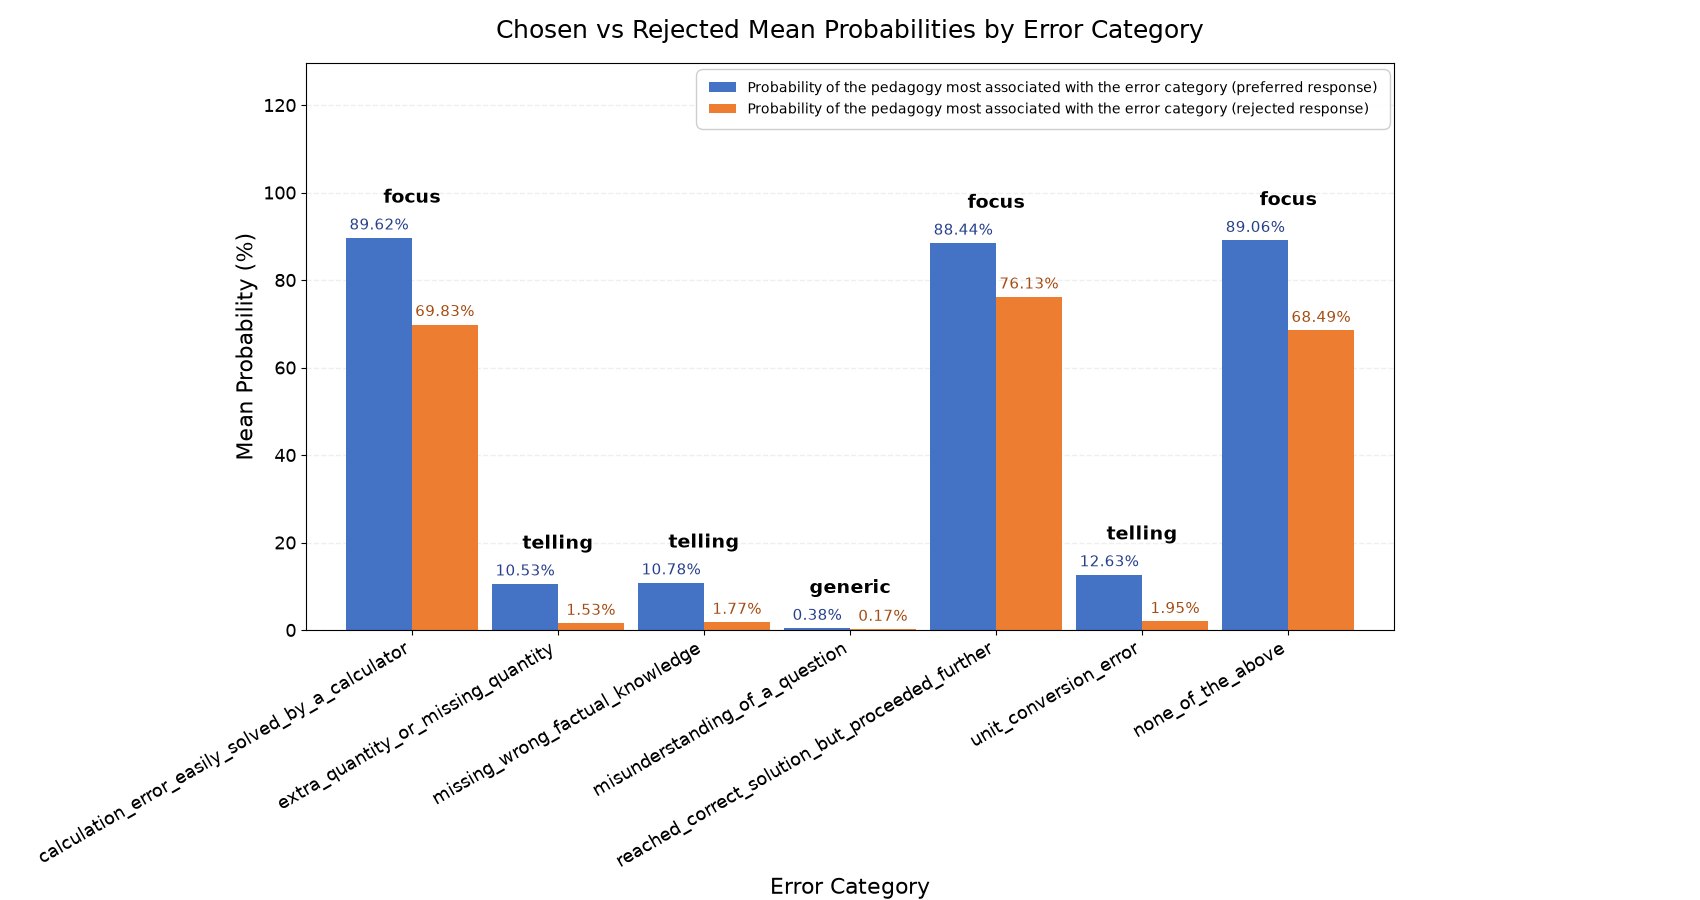

In [30]:
##################################################
# 2.1. Strong association: Even if the most strongly associated pedagogy is not the final chosen label, the soft labeling approach reflects this association well in the scores.
# - Figure (scaled visually to highlight even small values, without numeric bar value labels)
# - Pedagogy Alignment Figure
##################################################
import matplotlib.pyplot as plt
import numpy as np

# Prevent automatic cropping of figure margin space outside the plot area in Jupyter/Colab
try:
    from IPython import get_ipython
    get_ipython().run_line_magic(
        'config',
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None}"
    )
except:
    pass

# Sort so that 'none_of_the_above' is last, and all other error_categories are in alphabetical order
def sort_with_none_of_the_above_last(df, col, none_val='none_of_the_above'):
    # Sort alphabetically, except 'none_of_the_above' goes to the end
    df_no_none = df[df[col] != none_val].sort_values(by=col)
    df_none = df[df[col] == none_val]
    df_sorted = pd.concat([df_no_none, df_none], ignore_index=True)
    return df_sorted

results_sorted = sort_with_none_of_the_above_last(
    results_df,
    'error_category',
    'none_of_the_above'
).reset_index(drop=True)

# x-axis setup
x_labels = results_sorted['error_category']
x = np.arange(len(x_labels))

# Convert percentage string to float
def percent_to_float(p): return float(str(p).replace('%', ''))

chosen = results_sorted['chosen_mean_prob'].apply(percent_to_float)
rejected = results_sorted['rejected_mean_prob'].apply(percent_to_float)
max_pedagogy_labels = results_sorted['max_pedagogy']
chosen_mean_prob_strs = results_sorted['chosen_mean_prob']
rejected_mean_prob_strs = results_sorted['rejected_mean_prob']
width = 0.45
fig, ax = plt.subplots(figsize=(17, 9))

# bars
rects1 = ax.bar(x - width/2, chosen, width, label='Probability of the pedagogy most associated with the error category (preferred response)', color='#4472C4', zorder=2)
rects2 = ax.bar(x + width/2, rejected, width, label='Probability of the pedagogy most associated with the error category (rejected response)', color='#ED7D31', zorder=2)

# grid
ax.yaxis.grid(True, which='major', linestyle='--', linewidth=1, alpha=0.2, zorder=1)

# Labels above bars
for idx in range(len(x)):
    ch_height = rects1[idx].get_height()
    rj_height = rects2[idx].get_height()
    height = max(ch_height, rj_height)
    # Most-associated pedagogy label
    ax.text(x[idx], height + 7, str(max_pedagogy_labels.iloc[idx]), ha='center', va='bottom', fontsize=14, fontweight='bold', color='black', zorder=3)
    # chosen probability
    ax.text(x[idx] - width/2, ch_height + 1.1, str(chosen_mean_prob_strs.iloc[idx]), ha='center', va='bottom', fontsize=11, color='#26408B', fontweight='normal', zorder=4)
    # rejected probability
    ax.text(x[idx] + width/2, rj_height + 1.1, str(rejected_mean_prob_strs.iloc[idx]), ha='center', va='bottom', fontsize=11, color='#A54C13', fontweight='normal', zorder=4)

# Internal x-axis margins
num_cats = len(x)
xlim_left = -0.5 - width/2
xlim_right = num_cats - 0.5 + width/2
ax.set_xlim(left=xlim_left, right=xlim_right)

# y-axis
max_bar_height = max(chosen.max(), rejected.max())
legend_offset = 40
ax.set_ylim(bottom=0, top=max_bar_height + legend_offset)

# Axis labels / title
ax.set_ylabel('Mean Probability (%)', fontsize=16)
ax.set_xlabel('Error Category', fontsize=16)
ax.set_title('Chosen vs Rejected Mean Probabilities by Error Category', fontsize=18, pad=18)

# x-axis labels
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=13)
ax.tick_params(axis='y', labelsize=13)

# Legend
legend = ax.legend(loc='upper right', fontsize=10, frameon=True, markerscale=0.9, bbox_to_anchor=(0.996, 0.99))
legend.get_frame().set_alpha(0.96)
legend.get_frame().set_boxstyle('round,pad=0.5')

# Make canvas left and right margins the same, so it's 18% |--- plot ---| 18%
fig.subplots_adjust(left=0.18, right=0.82, bottom=0.30, top=0.93)

plt.show()

In [31]:
print("error_category:", response_pairs_df['error_category'][3000])

print("-" * 100)

print("chosen_label:", response_pairs_df['chosen_label'][3000])
print("chosen_score:", response_pairs_df['chosen_score'][3000])
print("chosen_label_prob_list:", response_pairs_df['chosen_label_prob_list'][3000])

print("-" * 100)

print("rejected_label:", response_pairs_df['rejected_label'][3000])
print("rejected_label_prob_list:", response_pairs_df['rejected_label_prob_list'][3000])
print("rejected_score:", response_pairs_df['rejected_score'][3000])


error_category: misunderstanding_of_a_question
----------------------------------------------------------------------------------------------------
chosen_label: focus
chosen_score: 0.0001695534603008
chosen_label_prob_list: [{'label': 'focus', 'probability': 0.929861}, {'label': 'probing', 'probability': 0.052978}, {'label': 'telling', 'probability': 0.014897}, {'label': 'generic', 'probability': 0.002264}]
----------------------------------------------------------------------------------------------------
rejected_label: focus
rejected_label_prob_list: [{'label': 'focus', 'probability': 0.832024}, {'label': 'telling', 'probability': 0.096003}, {'label': 'probing', 'probability': 0.070123}, {'label': 'generic', 'probability': 0.001849}]
rejected_score: 0.0001384736519859


In [32]:
response_pairs_df['chosen_label'][3000]

'focus'

In [33]:
response_pairs_df['chosen_score'][3000]

np.float64(0.0001695534603008)

In [34]:
response_pairs_df['chosen_label_prob_list'][3000]

"[{'label': 'focus', 'probability': 0.929861}, {'label': 'probing', 'probability': 0.052978}, {'label': 'telling', 'probability': 0.014897}, {'label': 'generic', 'probability': 0.002264}]"

In [35]:
##################################################
# 2.2. Soft-labeling actually provides additional information.
# - This supports the result of 2.1: Rather than only using the top-1 label, the soft labels related to student mistakes showed that the chosen response generally had a higher associated probability than the rejected response, and this nuance is well reflected in the PPMI scores.
# - In the majority of preference pairs (about 85.57%), the final top predicted label was the same for both the chosen and rejected responses.
# - Nevertheless, the fact that some pairs still differed between chosen and rejected is because the soft final pedagogy labels—combined with error category and pedagogy feature—provide additional association information.
# """ Although around 86% of pairs shared the same chosen_label and rejected_label, the association between error category and pedagogy is still captured by soft labeling.
# 85.6% of preference pairs shared the same top predicted pedagogy label, indicating that the proposed soft scoring function captured fine-grained pedagogical differences that would have been lost under hard-label matching. """
##################################################

In [36]:
# Calculate the number and ratio of pairs where chosen_label and rejected_label are the same or different
same_label_count = (response_pairs_df['chosen_label'] == response_pairs_df['rejected_label']).sum()
diff_label_count = (response_pairs_df['chosen_label'] != response_pairs_df['rejected_label']).sum()
total_count = len(response_pairs_df) 

same_label_ratio = same_label_count / total_count
diff_label_ratio = diff_label_count / total_count

print(f"Number of pairs where chosen_label and rejected_label are the same: {same_label_count} ({same_label_ratio:.2%})")
print(f"Number of pairs where chosen_label and rejected_label are different: {diff_label_count} ({diff_label_ratio:.2%})")

Number of pairs where chosen_label and rejected_label are the same: 20702 (85.20%)
Number of pairs where chosen_label and rejected_label are different: 3596 (14.80%)


In [37]:
import pandas as pd
response_pair_label_contingency_table = pd.crosstab(
    response_pairs_df['chosen_label'],
    response_pairs_df['rejected_label'],
    margins=True,
    margins_name='Total'
)

display(response_pair_label_contingency_table)

rejected_label,focus,generic,probing,telling,Total
chosen_label,,,,,
focus,20645,6,1041,439,22131
generic,7,0,0,0,7
probing,1043,1,57,0,1101
telling,1038,2,19,0,1059
Total,22733,9,1117,439,24298


In [38]:
# Count contingency table without margins
contingency = pd.crosstab(
    response_pairs_df['chosen_label'],
    response_pairs_df['rejected_label']
)

total_pairs = len(response_pairs_df)

# Overall percentage
contingency_percent = contingency / total_pairs * 100

# Add row totals
contingency_percent['Total'] = (
    contingency.sum(axis=1) / total_pairs * 100
)

# Add column totals
col_total = contingency.sum(axis=0) / total_pairs * 100
col_total['Total'] = 100.0

contingency_percent.loc['Total'] = col_total

display(
    contingency_percent.map(lambda x: f"{x:.2f}%")
)

rejected_label,focus,generic,probing,telling,Total
chosen_label,,,,,
focus,84.97%,0.02%,4.28%,1.81%,91.08%
generic,0.03%,0.00%,0.00%,0.00%,0.03%
probing,4.29%,0.00%,0.23%,0.00%,4.53%
telling,4.27%,0.01%,0.08%,0.00%,4.36%
Total,93.56%,0.04%,4.60%,1.81%,100.00%


---

## 3. raw score difference mean differently depending on the error cateogries 

- The issue of category scale in raw margins means that the numerical range of the PPMI (pedagogy–error association) scores differs for each student error category, so it is not valid to directly compare score differences across categories as absolute numbers.

- Specifically, the maximum coefficient value of the PPMI metric can vary significantly between error types.
    - For example, even if the margin observed in a calculation error and a misunderstanding error are both 0.1, these values have very different meanings.
    - Therefore, if we simply compute the raw score_difference as $(S_{chosen} - S_{rejected})$ and compare it across the entire dataset, the margin of specific error categories may overwhelm those of others, resulting in a distorted interpretation.
    - To address this issue, the study recommends using normalized margins for each category.

- However, since the scale of PPMI weights differs fundamentally by error category, it is not appropriate to compare raw score differences across categories to decide “in which category preference construction was more successful.”
    - For instance, the maximum PPMI for missing_wrong_factual_knowledge is 1.4188, while for extra_quantity_or_missing_quantity it is just 0.0579; thus, the absolute scales are inherently different.
    - Therefore, for category comparisons, the main metric should be the pedagogy probability shift described earlier, which is a much safer and more intuitive indicator than the raw score gap.

#### 3.1. Raw score difference

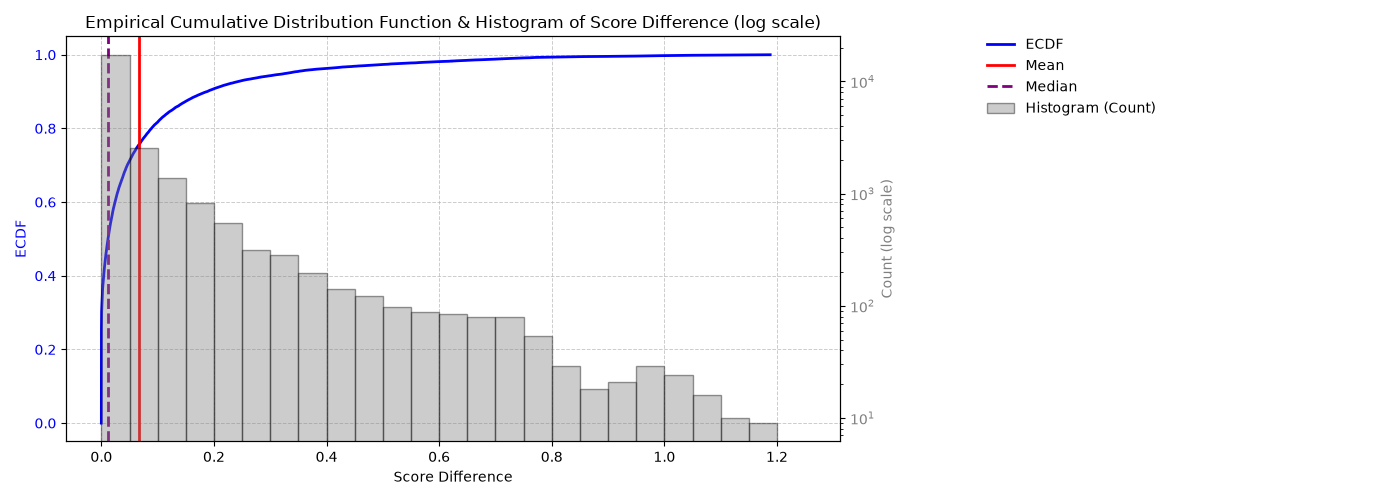

In [39]:
##################################################
# 3. Margin statistics (overall scale)
# - Show that the actual raw margin is small.
# - It is inappropriate to evaluate performance solely using raw margin; margins should be normalized according to PPMI.
##################################################

import numpy as np
import matplotlib.lines as mlines

def plot_ecdf(series, label, color, lw=2, ax=None):
    sorted_vals = np.sort(series)
    ecdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    if ax is None:
        ax = plt.gca()
    ax.plot(sorted_vals, ecdf, label=label, color=color, lw=lw)

# Prepare values
score_diff = response_pairs_df['score_difference'].astype(float)

# Calculate mean and median
mean_val = score_diff.mean()
median_val = score_diff.median()

fig, ax1 = plt.subplots(figsize=(14, 5))

# Set x-axis range and bins (interval: 0.05)
xmin = np.floor(score_diff.min() / 0.05) * 0.05
xmax = np.ceil(score_diff.max() / 0.05) * 0.05
bins = np.arange(xmin, xmax + 0.05, 0.05)

# ECDF
plot_ecdf(score_diff, label='ECDF', color='blue', ax=ax1)
ax1.set_xlabel('Score Difference')
ax1.set_ylabel('ECDF', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(axis='both', linestyle='--', linewidth=0.7, alpha=0.65, zorder=0)

# Draw mean and median lines (include them in the legend)
mean_line = ax1.axvline(mean_val, color='red', linestyle='-', lw=2, label='Mean')
median_line = ax1.axvline(median_val, color='purple', linestyle='--', lw=2, label='Median')

# Histogram (right y-axis - count, with log scale)
ax2 = ax1.twinx()
hist_vals = ax2.hist(
    score_diff, 
    bins=bins, color='gray', edgecolor='black', alpha=0.4, label='Histogram (Count)'
)
ax2.set_ylabel('Count (log scale)', color='gray')
ax2.set_yscale('log')  # Use log scale
ax2.tick_params(axis='y', labelcolor='gray')

# Legend: manually set handles to include lines for mean/median and histogram
ecdf_handle = mlines.Line2D([], [], color='blue', label='ECDF', lw=2)
mean_handle = mlines.Line2D([], [], color='red', linestyle='-', lw=2, label='Mean')
median_handle = mlines.Line2D([], [], color='purple', linestyle='--', lw=2, label='Median')
hist_patch = ax2.patches[0] if ax2.patches else None
hist_handle = None
if hist_patch is not None:
    from matplotlib.patches import Patch
    hist_handle = Patch(facecolor='gray', alpha=0.4, label='Histogram (Count)', edgecolor='black')
    handles = [ecdf_handle, mean_handle, median_handle, hist_handle]
else:
    handles = [ecdf_handle, mean_handle, median_handle]

# Place the legend outside the plot area (further to the right and higher up)
ax1.legend(
    handles=handles, 
    loc='center left', 
    bbox_to_anchor=(1.18, 0.9),  # further right and up
    borderaxespad=0.1, 
    frameon=False
)

plt.title("Empirical Cumulative Distribution Function & Histogram of Score Difference (log scale)")
plt.tight_layout(rect=[0, 0, 0.88, 1])  # More space on the right for the plot

plt.show()

In [40]:
###################################################
# 3. Margin (Category Scale)
# The maximum PPMI value by category ranges from a minimum of 0.0579 to a maximum of 1.4188, a difference of about 24.5 times.
# Therefore, comparing the margin of calculation error (0.20) and misunderstanding (0.0002) on the same scale is incorrect.
# However, since the current pairing sorts only within the same context, the chosen/rejected ranking itself does not have cross-category scaling issues.
# The problematic aspect:
#  - It is not appropriate to set a threshold based on the interpretation that a larger margin means a more certain preference.
# Solution:
#  - Use a normalized margin for each error category.
##################################################
grouped_statistic = response_pairs_df.groupby("error_category").agg(
    unique_context_count = ("context_data_idx", "nunique"),
    number_of_pairs = ("context_data_idx", "count"),
    score_difference_mean = ("score_difference", "mean"),
    score_difference_median = ("score_difference", "median")
)

# Sort by number_of_pairs in descending order, excluding the total (which will be manually added last)
grouped_statistic_sorted = grouped_statistic.sort_values(by="number_of_pairs", ascending=False)

# Add a total row (to appear at the end)
total_row = pd.DataFrame({
    "unique_context_count": [grouped_statistic["unique_context_count"].sum()],
    "number_of_pairs": [grouped_statistic["number_of_pairs"].sum()],
    "score_difference_mean": ["total mean: " + str(round(response_pairs_df["score_difference"].mean(), 6))],
    "score_difference_median": ["total median: " + str(round(response_pairs_df["score_difference"].median(), 6))]
}, index=["total"])

result = pd.concat([grouped_statistic_sorted, total_row])

result

,unique_context_count,number_of_pairs,score_difference_mean,score_difference_median
misunderstanding_of_a_question,199,6966,0.000164,0.000066
extra_quantity_or_missing_quantity,167,5874,0.042154,0.011844
missing_wrong_factual_knowledge,97,3398,0.14254,0.058414
calculation_error_easily_solved_by_a_calculator,87,3032,0.177833,0.102862
none_of_the_above,60,2106,0.061043,0.038189
reached_correct_solution_but_proceeded_further,49,1718,0.024395,0.010142
unit_conversion_error,34,1204,0.137214,0.055729
total,693,24298,total mean: 0.066177,total median: 0.011785


In [41]:
##################################################
# PPMI table again
##################################################


# For each error category (column), get the pedagogy (index) with the highest PPMI value:
ppmi_max_pedagogy_per_error = ppmi_table.idxmax()

# Combine highest-PPMI pedagogy and its value per error category into a DataFrame
max_ppmi_df = pd.DataFrame({
    "error_category": ppmi_max_pedagogy_per_error.index ,
    "max_pedagogy": ppmi_max_pedagogy_per_error.values,
    "max_ppmi_value": [ppmi_table.loc[ped, err] for err, ped in zip(ppmi_max_pedagogy_per_error.index, ppmi_max_pedagogy_per_error.values)]
})

display(max_ppmi_df.sort_values(by="max_ppmi_value", ascending=False))

print("ratio between max and min PPMI value: ", round(max_ppmi_df['max_ppmi_value'].max() / max_ppmi_df['max_ppmi_value'].min(), 2))

,error_category,max_pedagogy,max_ppmi_value
2,missing_wrong_factual_knowledge,telling,1.666874
6,unit_conversion_error,telling,1.179324
0,calculation_error_easily_solved_by_a_calculator,focus,0.898611
1,extra_quantity_or_missing_quantity,telling,0.468045
4,none_of_the_above,focus,0.297160
5,reached_correct_solution_but_proceeded_further,focus,0.267413
3,misunderstanding_of_a_question,generic,0.074891


ratio between max and min PPMI value:  22.26


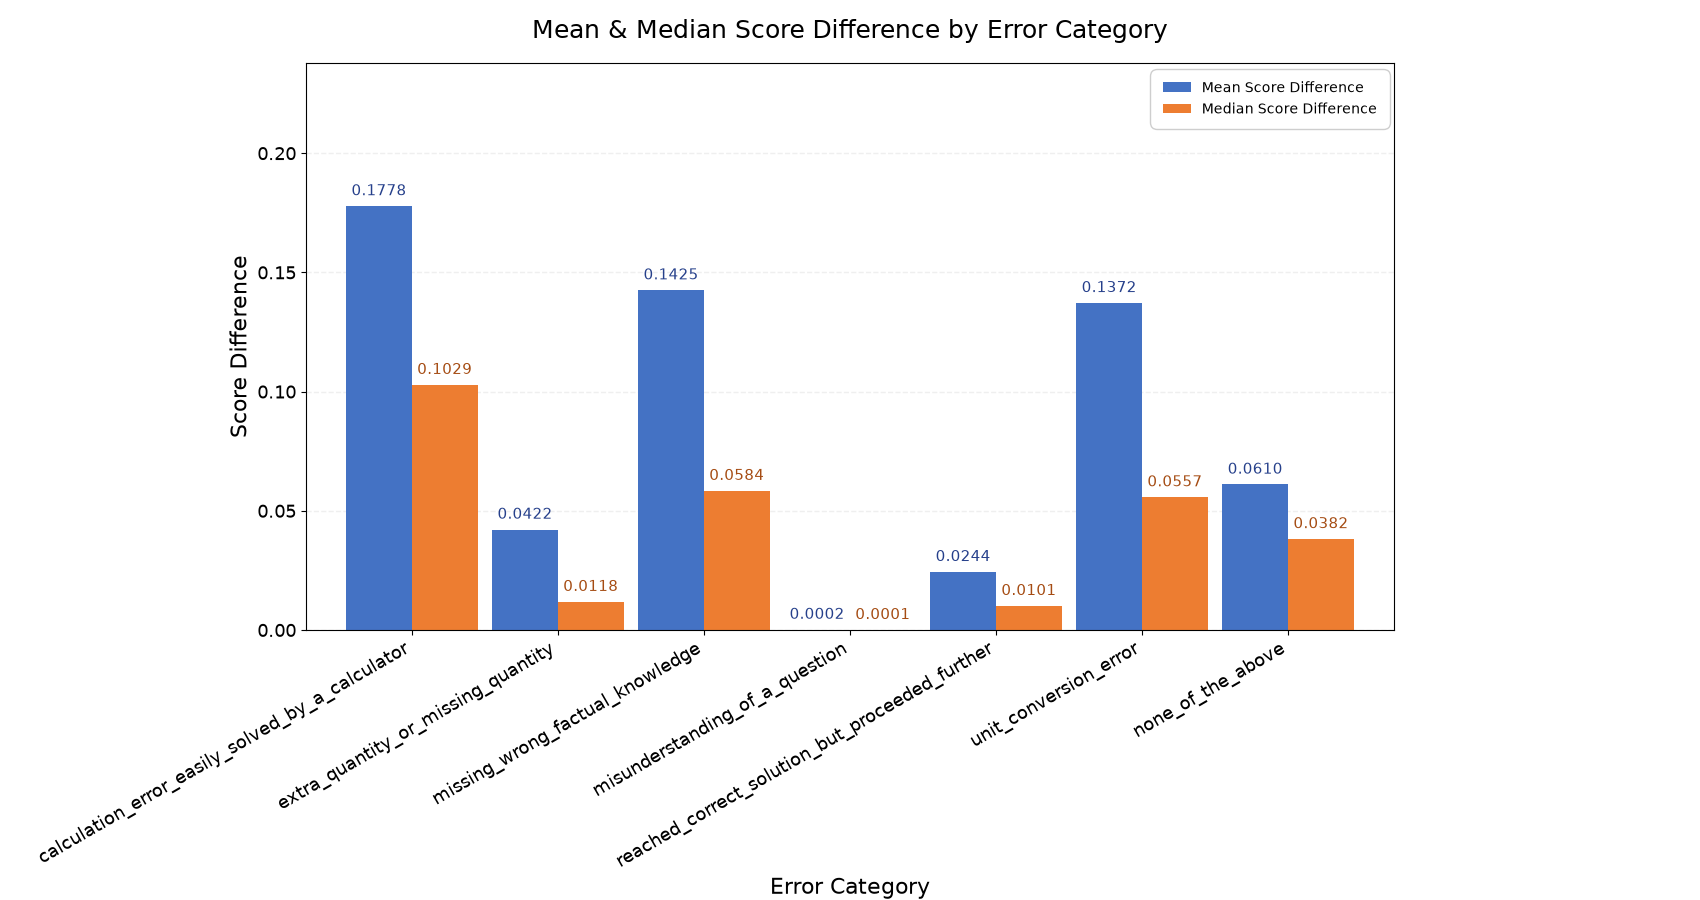

In [42]:
###################################################
# 3. About the Margin (Category Scale)
# The maximum PPMI value for error categories ranges from a minimum of 0.0579 to a maximum of 1.4188, a difference of about 24.5 times.
# Therefore, it is inappropriate to compare the margin of 0.20 for "calculation error" and the margin of 0.0002 for "misunderstanding" on the same scale.
###################################################

import matplotlib.pyplot as plt
import numpy as np

# We already have groupby statistics, so reuse them
stat = grouped_statistic_sorted.copy()

# For error_category, "none_of_the_above" always comes last, the others are in alphabetical order, and "total" comes last (not shown on x-axis)
none_of_above = 'none_of_the_above'
total = 'total'
cat_list = list(stat.index)

# Exclude 'none_of_the_above' and 'total', then sort alphabetically
main_cats = [cat for cat in cat_list if cat != none_of_above and cat != total]
main_cats_sorted = sorted(main_cats)

# Add 'none_of_the_above' to the end, and do not include 'total' on the x-axis
if none_of_above in stat.index:
    new_order = main_cats_sorted + [none_of_above]
else:
    new_order = main_cats_sorted

stat_sorted_custom = stat.loc[new_order]

x_labels = list(stat_sorted_custom.index)
x = np.arange(len(x_labels))

# Convert mean/median values to float (skip conversion for "total" row, which is a string)
means = []
medians = []
for idx, row in stat_sorted_custom.iterrows():
    try:
        means.append(float(row['score_difference_mean']))
    except:
        means.append(np.nan)
    try:
        medians.append(float(row['score_difference_median']))
    except:
        medians.append(np.nan)
means = np.array(means)
medians = np.array(medians)

width = 0.45
fig, ax = plt.subplots(figsize=(17, 9))

rects1 = ax.bar(x - width/2, means, width, label='Mean Score Difference', color='#4472C4', zorder=2)
rects2 = ax.bar(x + width/2, medians, width, label='Median Score Difference', color='#ED7D31', zorder=2)

ax.yaxis.grid(True, which='major', linestyle='--', linewidth=1, alpha=0.2, zorder=1)

# Show values on top of bars (skip if value is NaN)
for idx in range(len(x)):
    if not np.isnan(means[idx]):
        ax.text(
            x[idx] - width/2, means[idx] + 0.003, f"{means[idx]:.4f}",
            ha='center', va='bottom', fontsize=11, color='#26408B',
            fontweight='normal', zorder=4
        )
    if not np.isnan(medians[idx]):
        ax.text(
            x[idx] + width/2, medians[idx] + 0.003, f"{medians[idx]:.4f}",
            ha='center', va='bottom', fontsize=11, color='#A54C13',
            fontweight='normal', zorder=4
        )

num_cats = len(x)
xlim_left = -0.5 - width/2
xlim_right = num_cats - 0.5 + width/2
ax.set_xlim(left=xlim_left, right=xlim_right)

max_bar_height = np.nanmax([means, medians])  # ignore nan
ax.set_ylim(bottom=0, top=max_bar_height + 0.06)

ax.set_ylabel('Score Difference', fontsize=16)
ax.set_xlabel('Error Category', fontsize=16)
ax.set_title('Mean & Median Score Difference by Error Category', fontsize=18, pad=18)

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=13)
ax.tick_params(axis='y', labelsize=13)

legend = ax.legend(loc='upper right', fontsize=10, frameon=True, markerscale=0.9, bbox_to_anchor=(0.996, 0.99))
legend.get_frame().set_alpha(0.96)
legend.get_frame().set_boxstyle('round,pad=0.5')

fig.subplots_adjust(left=0.18, right=0.82, bottom=0.30, top=0.93)
plt.show()

----

## Normalized score difference

In [43]:
# 1. Get the maximum PPMI for each error category
max_ppmi_per_error = ppmi_table.max(axis=0)

# 2. Each preference pair's raw margin
response_pairs_df["score_difference"] 

# 3. Map each pair's error category to its max PPMI
response_pairs_df["max_ppmi"] = (
    response_pairs_df["error_category"]
    .map(max_ppmi_per_error)
)

# 4. Calculate the normalized margin
response_pairs_df["normalized_score_difference"] = (
    response_pairs_df["score_difference"]
    / response_pairs_df["max_ppmi"]
)

# 5. Calculate percentile thresholds across all pairs
q25 = response_pairs_df["normalized_score_difference"].quantile(0.25)
q50 = response_pairs_df["normalized_score_difference"].quantile(0.50)
q75 = response_pairs_df["normalized_score_difference"].quantile(0.75)
q80 = response_pairs_df["normalized_score_difference"].quantile(0.80)
q90 = response_pairs_df["normalized_score_difference"].quantile(0.90)

# 6. Print statistics for normalized score difference by category
print("25th percentile:", q25 )
print("50th percentile:", q50)
print("75th percentile:", q75)
print("80th percentile:", q80)
print("90th percentile:", q90)

25th percentile: 0.001720381038752932
50th percentile: 0.01985228884373954
75th percentile: 0.08875952339097726
80th percentile: 0.12612951579143108
90th percentile: 0.2890310185819135


In [44]:

count_above_01 = (response_pairs_df["normalized_score_difference"] > 0.1).sum()
ratio_above_01 = (response_pairs_df["normalized_score_difference"] > 0.1).sum() / len(response_pairs_df)
print("total count:", len(response_pairs_df))
print("normalized_score_difference > 0.1 count:", count_above_01)
print("normalized_score_difference > 0.1 ratio:", ratio_above_01)

total count: 24298
normalized_score_difference > 0.1 count: 5615
normalized_score_difference > 0.1 ratio: 0.23108897851675034


In [45]:
grouped_statistic = response_pairs_df.groupby("error_category").agg(
    unique_context_count = ("context_data_idx", "nunique"),
    number_of_pairs = ("context_data_idx", "count"),
    normalized_score_difference_mean = ("normalized_score_difference", "mean"),
    normalized_score_difference_median = ("normalized_score_difference", "median")
)

# Sort by number_of_pairs descending, excluding 'total' (total will be manually added at the end)
grouped_statistic_sorted = grouped_statistic.sort_values(by="number_of_pairs", ascending=False)

# Add total row (ensure it's at the bottom)
total_row = pd.DataFrame({
    "unique_context_count": [grouped_statistic["unique_context_count"].sum()],
    "number_of_pairs": [grouped_statistic["number_of_pairs"].sum()],
    "normalized_score_difference_mean": ["total mean: " + str(round(response_pairs_df["normalized_score_difference"].mean(), 6))],
    "normalized_score_difference_median": ["total median: " + str(round(response_pairs_df["normalized_score_difference"].median(), 6))]
}, index=["total"])

result = pd.concat([grouped_statistic_sorted, total_row])

result

,unique_context_count,number_of_pairs,normalized_score_difference_mean,normalized_score_difference_median
misunderstanding_of_a_question,199,6966,0.002196,0.000883
extra_quantity_or_missing_quantity,167,5874,0.090065,0.025305
missing_wrong_factual_knowledge,97,3398,0.085513,0.035044
calculation_error_easily_solved_by_a_calculator,87,3032,0.197897,0.114468
none_of_the_above,60,2106,0.20542,0.128513
reached_correct_solution_but_proceeded_further,49,1718,0.091225,0.037925
unit_conversion_error,34,1204,0.11635,0.047255
total,693,24298,total mean: 0.089076,total median: 0.019852


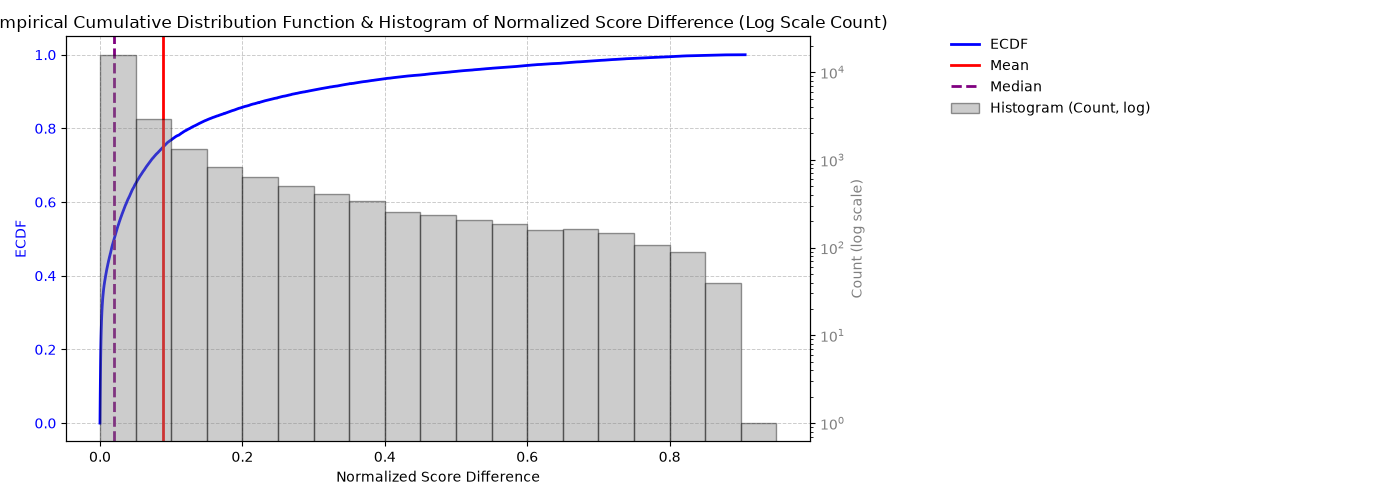

In [46]:
##################################################
# 3. Margin analysis (global scale)
# - Show that the actual raw margin itself is small
# - The margin should not be interpreted using the raw margin; it must be normalized by PPMI
##################################################

import numpy as np
import matplotlib.lines as mlines

def plot_ecdf(series, label, color, lw=2, ax=None):
    sorted_vals = np.sort(series)
    ecdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    if ax is None:
        ax = plt.gca()
    ax.plot(sorted_vals, ecdf, label=label, color=color, lw=lw)

# Prepare values: use normalized_score_difference
score_diff = response_pairs_df['normalized_score_difference'].astype(float)

# Calculate mean and median
mean_val = score_diff.mean()
median_val = score_diff.median()

fig, ax1 = plt.subplots(figsize=(14, 5))

# Set x-axis range and bins (step size: 0.05)
xmin = np.floor(score_diff.min() / 0.05) * 0.05
xmax = np.ceil(score_diff.max() / 0.05) * 0.05
bins = np.arange(xmin, xmax + 0.05, 0.05)

# ECDF
plot_ecdf(score_diff, label='ECDF', color='blue', ax=ax1)
ax1.set_xlabel('Normalized Score Difference')
ax1.set_ylabel('ECDF', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(axis='both', linestyle='--', linewidth=0.7, alpha=0.65, zorder=0)

# Plot mean and median lines, also include in legend
mean_line = ax1.axvline(mean_val, color='red', linestyle='-', lw=2, label='Mean')
median_line = ax1.axvline(median_val, color='purple', linestyle='--', lw=2, label='Median')

# Histogram (right y-axis - count, log scale)
ax2 = ax1.twinx()
hist_vals = ax2.hist(
    score_diff, 
    bins=bins, color='gray', edgecolor='black', alpha=0.4, label='Histogram (Count)', log=True
)
ax2.set_ylabel('Count (log scale)', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')
ax2.set_yscale('log')

# Add mean and median lines (handles) to legend manually
ecdf_handle = mlines.Line2D([], [], color='blue', label='ECDF', lw=2)
mean_handle = mlines.Line2D([], [], color='red', linestyle='-', lw=2, label='Mean')
median_handle = mlines.Line2D([], [], color='purple', linestyle='--', lw=2, label='Median')
hist_patch = ax2.patches[0] if ax2.patches else None
hist_handle = None
if hist_patch is not None:
    from matplotlib.patches import Patch
    hist_handle = Patch(facecolor='gray', alpha=0.4, label='Histogram (Count, log)', edgecolor='black')
    handles = [ecdf_handle, mean_handle, median_handle, hist_handle]
else:
    handles = [ecdf_handle, mean_handle, median_handle]

# Place the legend outside the graph (further to the right and upper)
ax1.legend(
    handles=handles, 
    loc='center left', 
    bbox_to_anchor=(1.18, 0.9),
    borderaxespad=0.1,
    frameon=False
)

plt.title("Empirical Cumulative Distribution Function & Histogram of Normalized Score Difference (Log Scale Count)")
plt.tight_layout(rect=[0, 0, 0.88, 1])  # Expand space on the right for the plot

plt.show()

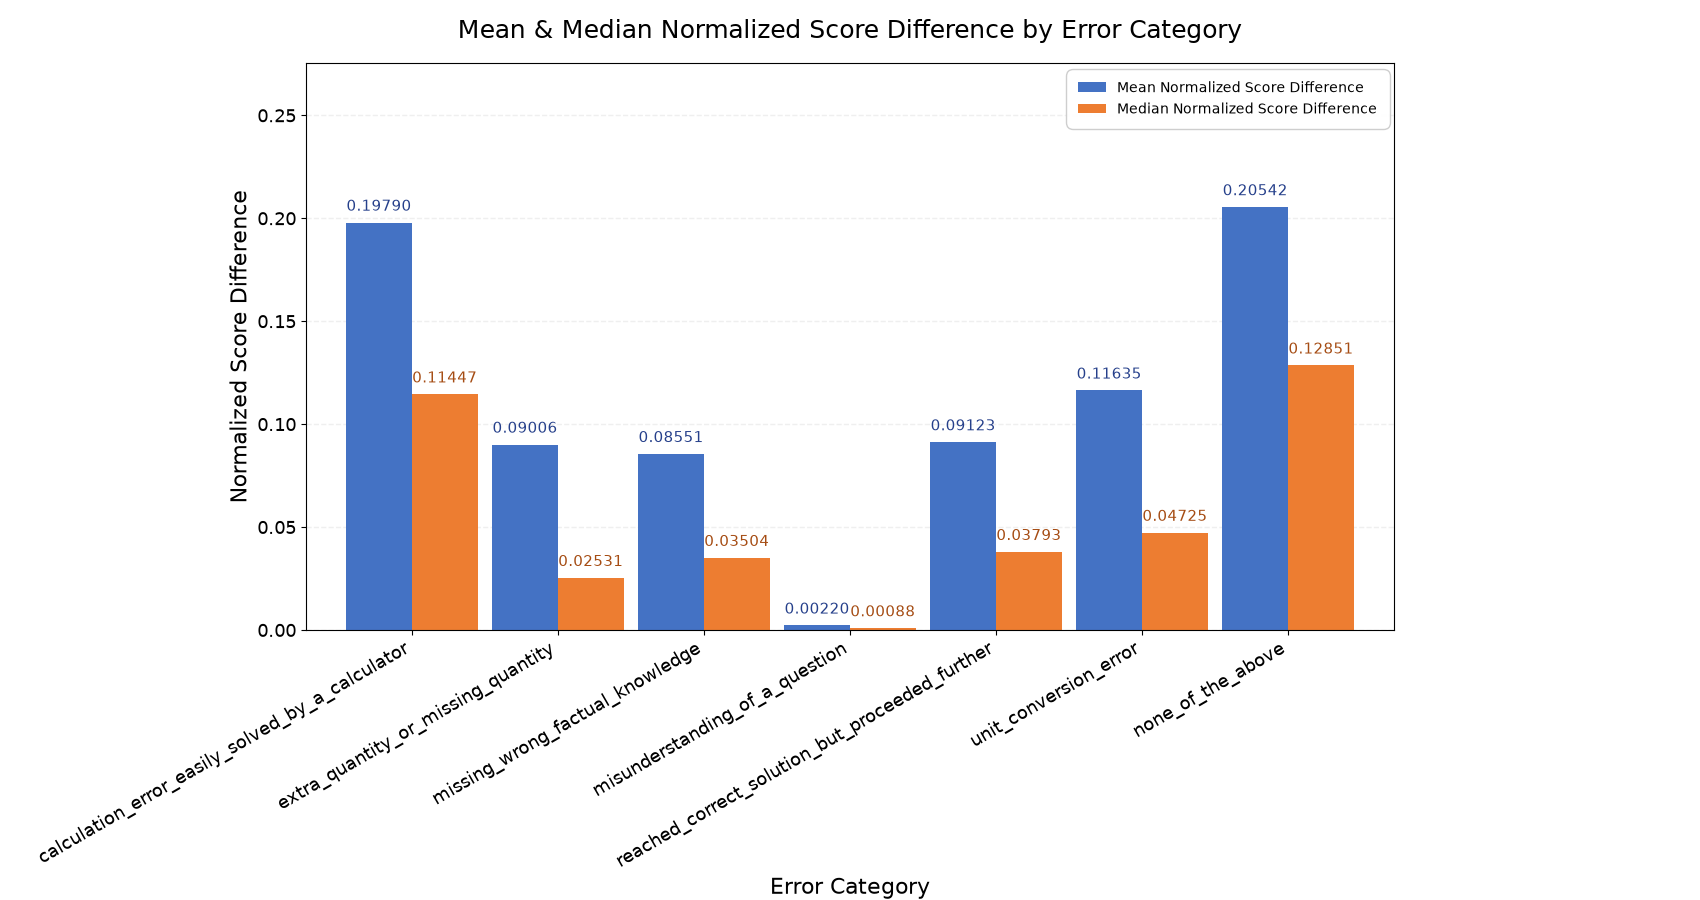

In [47]:
###################################################
# 3. About Margin (Category Scale)
# The maximum PPMI category ranges from a minimum of 0.0579 to a maximum of 1.4188—about a 24.5x difference.
# Therefore, directly comparing the margin of calculation error (0.20) with that of misunderstanding (0.0002) on the same scale is inappropriate.
# → Use normalized_score_difference for comparison.
###################################################

import matplotlib.pyplot as plt
import numpy as np

# Use the existing groupby statistics
stat = grouped_statistic_sorted.copy()

# In error_category, "none_of_the_above" should always come last, the others should be in alphabetical order, and 'total' comes after.
none_of_above = 'none_of_the_above'
total = 'total'
cat_list = list(stat.index)

# Sort all categories alphabetically except 'none_of_the_above' and 'total'
main_cats = [cat for cat in cat_list if cat != none_of_above and cat != total]
main_cats_sorted = sorted(main_cats)

# Add 'none_of_the_above' at the end; do not display 'total' on the x-axis
if none_of_above in stat.index:
    new_order = main_cats_sorted + [none_of_above]
else:
    new_order = main_cats_sorted

stat_sorted_custom = stat.loc[new_order]

x_labels = list(stat_sorted_custom.index)
x = np.arange(len(x_labels))

# Convert normalized mean/median values to float (skip 'total' row, which is a string)
norm_means = []
norm_medians = []
for idx, row in stat_sorted_custom.iterrows():
    try:
        norm_means.append(float(row['normalized_score_difference_mean']))
    except:
        norm_means.append(np.nan)
    try:
        norm_medians.append(float(row['normalized_score_difference_median']))
    except:
        norm_medians.append(np.nan)
norm_means = np.array(norm_means)
norm_medians = np.array(norm_medians)

width = 0.45
fig, ax = plt.subplots(figsize=(17, 9))

rects1 = ax.bar(x - width/2, norm_means, width, label='Mean Normalized Score Difference', color='#4472C4', zorder=2)
rects2 = ax.bar(x + width/2, norm_medians, width, label='Median Normalized Score Difference', color='#ED7D31', zorder=2)

ax.yaxis.grid(True, which='major', linestyle='--', linewidth=1, alpha=0.2, zorder=1)

# Show value labels above bars (do not display for NaN values)
for idx in range(len(x)):
    if not np.isnan(norm_means[idx]):
        ax.text(x[idx] - width/2, norm_means[idx] + 0.004, f"{norm_means[idx]:.5f}", ha='center', va='bottom', fontsize=11, color='#26408B', fontweight='normal', zorder=4)
    if not np.isnan(norm_medians[idx]):
        ax.text(x[idx] + width/2, norm_medians[idx] + 0.004, f"{norm_medians[idx]:.5f}", ha='center', va='bottom', fontsize=11, color='#A54C13', fontweight='normal', zorder=4)

num_cats = len(x)
xlim_left = -0.5 - width/2
xlim_right = num_cats - 0.5 + width/2
ax.set_xlim(left=xlim_left, right=xlim_right)

max_bar_height = np.nanmax([norm_means, norm_medians])  # Exclude nan values
ax.set_ylim(bottom=0, top=max_bar_height + 0.07)

ax.set_ylabel('Normalized Score Difference', fontsize=16)
ax.set_xlabel('Error Category', fontsize=16)
ax.set_title('Mean & Median Normalized Score Difference by Error Category', fontsize=18, pad=18)

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=13)
ax.tick_params(axis='y', labelsize=13)

legend = ax.legend(loc='upper right', fontsize=10, frameon=True, markerscale=0.9, bbox_to_anchor=(0.996, 0.99))
legend.get_frame().set_alpha(0.96)
legend.get_frame().set_boxstyle('round,pad=0.5')

fig.subplots_adjust(left=0.18, right=0.82, bottom=0.30, top=0.93)
plt.show()

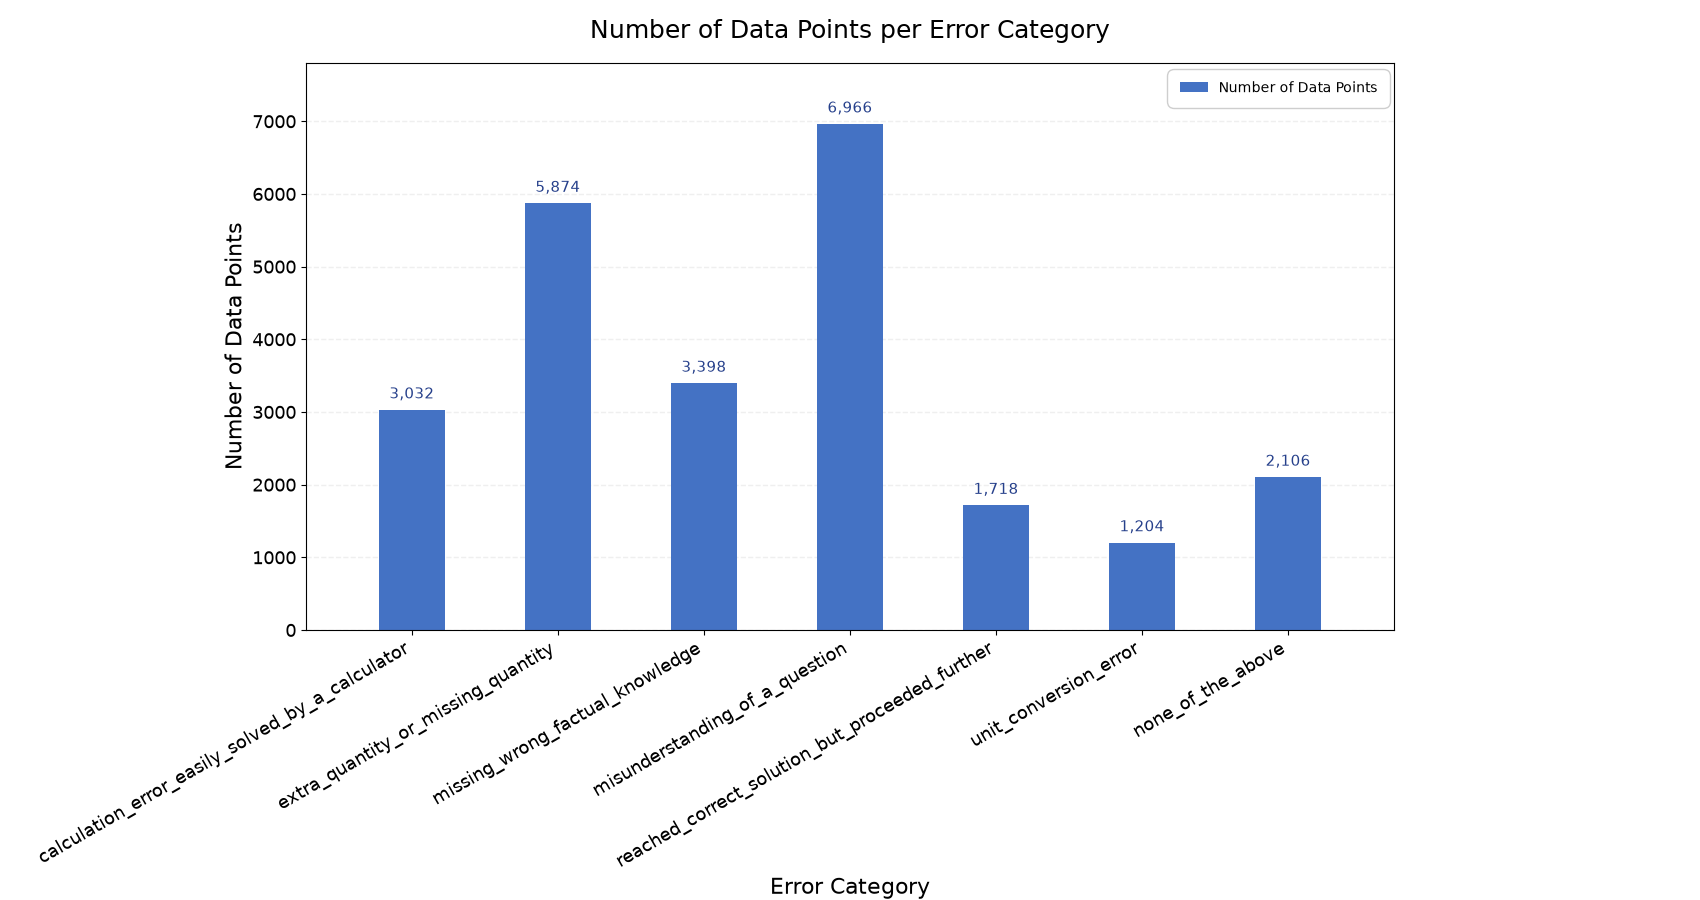

In [48]:
# Number of Data Points per Error Category

import matplotlib.pyplot as plt
import numpy as np

error_counts = response_pairs_df['error_category'].value_counts()
none_of_above = 'none_of_the_above'
total = 'total'
cat_list = list(error_counts.index)
main_cats = [cat for cat in cat_list if cat != none_of_above and cat != total]
main_cats_sorted = sorted(main_cats)
new_order = main_cats_sorted + [none_of_above] if none_of_above in error_counts.index else main_cats_sorted
error_counts_sorted = error_counts.loc[new_order]

x_labels = list(error_counts_sorted.index)
x = np.arange(len(x_labels))
counts = error_counts_sorted.to_numpy(dtype=float)

width = 0.45
fig, ax = plt.subplots(figsize=(17, 9))
rects = ax.bar(x, counts, width, label='Number of Data Points', color='#4472C4', zorder=2)
ax.yaxis.grid(True, which='major', linestyle='--', linewidth=1, alpha=0.2, zorder=1)

max_bar_height = np.nanmax(counts)
label_offset = max_bar_height * 0.015

for idx in range(len(x)):
    if not np.isnan(counts[idx]):
        ax.text(x[idx], counts[idx] + label_offset, f"{int(counts[idx]):,}", ha='center', va='bottom', fontsize=11, color='#26408B', fontweight='normal', zorder=4)

num_cats = len(x)
xlim_left = -0.5 - width / 2
xlim_right = num_cats - 0.5 + width / 2
ax.set_xlim(left=xlim_left, right=xlim_right)
ax.set_ylim(bottom=0, top=max_bar_height + max_bar_height * 0.12)
ax.set_ylabel('Number of Data Points', fontsize=16)
ax.set_xlabel('Error Category', fontsize=16)
ax.set_title('Number of Data Points per Error Category', fontsize=18, pad=18)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=13)
ax.tick_params(axis='y', labelsize=13)

legend = ax.legend(loc='upper right', fontsize=10, frameon=True, markerscale=0.9, bbox_to_anchor=(0.996, 0.99))
legend.get_frame().set_alpha(0.96)
legend.get_frame().set_boxstyle('round,pad=0.5')
fig.subplots_adjust(left=0.18, right=0.82, bottom=0.30, top=0.93)
plt.show()

---

## 4. Model Statistic 

In [49]:
from collections import Counter

# Model statistics overview

# Score statistics for each chosen_model
chosen_stats = response_pairs_df.groupby('chosen_model')['chosen_score'].agg(['mean', 'min', 'max', 'median', 'count']).sort_values('count', ascending=False)
print("Score statistics by chosen_model")
print(chosen_stats.sort_values(by='mean', ascending=False), end="\n\n")
print("-"*100)

# Score statistics for each rejected_model
rejected_stats = response_pairs_df.groupby('rejected_model')['rejected_score'].agg(['mean', 'min', 'max', 'median', 'count']).sort_values('count', ascending=False)
print("Score statistics by rejected_model")
print(rejected_stats.sort_values(by='mean', ascending=False), end="\n\n")
print("-"*100)


chosen_model_counts = Counter(response_pairs_df['chosen_model'])
rejected_model_counts = Counter(response_pairs_df['rejected_model'])
all_models = set(chosen_model_counts) | set(rejected_model_counts)

model_stats = []
for model in sorted(all_models):
    chosen_count = chosen_model_counts.get(model, 0)
    rejected_count = rejected_model_counts.get(model, 0)
    chosen_rejected_ratio = chosen_count / (chosen_count + rejected_count)
    model_stats.append({
        'model': model, 
        'chosen_count': chosen_count, 
        'rejected_count': rejected_count,
        'chosen_rejected_ratio': chosen_rejected_ratio
        })

model_stats_df = pd.DataFrame(model_stats).sort_values(by='chosen_rejected_ratio', ascending=False)
print("Count of each model as chosen_model and rejected_model")
print(model_stats_df.reset_index(drop=True).sort_values(by='chosen_rejected_ratio', ascending=False))

Score statistics by chosen_model
                           mean       min       max    median  count
chosen_model                                                        
llama3.1-8b            0.240651  0.000112  1.402018  0.099795   3974
gemini-3.5-flash-lite  0.237969  0.000104  0.836967  0.256034   2928
llama3.2:3b            0.231327  0.000104  1.424625  0.050227   4070
llama3.2:1b            0.223602  0.000107  1.276251  0.060604   4734
mistral-nemo:12b       0.221320  0.000106  1.493276  0.069083   4301
gpt-5.6-terra          0.218124  0.000105  1.500340  0.070462   4291

----------------------------------------------------------------------------------------------------
Score statistics by rejected_model
                           mean       min       max    median  count
rejected_model                                                      
gpt-5.6-terra          0.215959  0.000073  0.809696  0.176882   3347
llama3.2:1b            0.166809  0.000070  0.810443  0.014669   3540
mi

---

In [50]:
ppmi_max_pedagogy_per_error = ppmi_table.idxmax()
# Combine the highest-PPMI pedagogy and its value per error category into a DataFrame
max_ppmi_df = pd.DataFrame({
    "error_category": ppmi_max_pedagogy_per_error.index,
    "max_pedagogy": ppmi_max_pedagogy_per_error.values,
    "max_ppmi_value": [ppmi_table.loc[ped, err] for err, ped in zip(ppmi_max_pedagogy_per_error.index, ppmi_max_pedagogy_per_error.values)]
})

display(max_ppmi_df)

,error_category,max_pedagogy,max_ppmi_value
0,calculation_error_easily_solved_by_a_calculator,focus,0.898611
1,extra_quantity_or_missing_quantity,telling,0.468045
2,missing_wrong_factual_knowledge,telling,1.666874
3,misunderstanding_of_a_question,generic,0.074891
4,none_of_the_above,focus,0.297160
5,reached_correct_solution_but_proceeded_further,focus,0.267413
6,unit_conversion_error,telling,1.179324


In [51]:
# 각 error_category별로 상위 80% 데이터를 가져왔을 때 
# 각 error_category별 갯수와 normalized_score_difference의 mean, max, min(80% 데이터 기준) 구하기 
# total 행은 top_80_percent_count 합만 계산(다른 통계 불포함), 테이블은 mean 내림차순 정렬 후 total을 맨 아래에 추가

top_80_rows = []
for category, group in response_pairs_df.groupby('error_category'):
    group_sorted = group.sort_values(by='score_difference', ascending=False)
    n_top = int(len(group_sorted) * 0.8)
    n_top = max(n_top, 1)
    top_80_group = group_sorted.head(n_top)
    mean_norm_diff = top_80_group['normalized_score_difference'].mean()
    max_norm_diff = top_80_group['normalized_score_difference'].max()
    min_norm_diff = top_80_group['normalized_score_difference'].min()
    top_80_rows.append({
        "error_category": category,
        "top_80_percent_count": n_top,
        "norm_score_diff_mean": mean_norm_diff,
        "norm_score_diff_max": max_norm_diff,
        "norm_score_diff_min": min_norm_diff,
    })

# DataFrame 생성 및 mean 내림차순 정렬
top_80_df = pd.DataFrame(top_80_rows, columns=[
    "error_category", 
    "top_80_percent_count", 
    "norm_score_diff_mean", 
    "norm_score_diff_max", 
    "norm_score_diff_min"
]).sort_values(by='norm_score_diff_mean', ascending=False).reset_index(drop=True)

# total row 추가 (top_80_percent_count에 대해서만, 통계값은 빈 칸)
total_count = top_80_df['top_80_percent_count'].sum()
total_row = {
    "error_category": "total",
    "top_80_percent_count": total_count,
    "norm_score_diff_mean": "",
    "norm_score_diff_max": "",
    "norm_score_diff_min": ""
}

# total 행 맨 아래에 추가
top_80_df_final = pd.concat([top_80_df, pd.DataFrame([total_row])], ignore_index=True)
display(top_80_df_final)

,error_category,top_80_percent_count,norm_score_diff_mean,norm_score_diff_max,norm_score_diff_min
0,none_of_the_above,1684,0.252317,0.898772,0.038992
1,calculation_error_easily_solved_by_a_calculator,2425,0.243326,0.898947,0.033426
2,unit_conversion_error,963,0.143843,0.865011,0.013733
3,reached_correct_solution_but_proceeded_further,1374,0.11249,0.897755,0.01258
4,extra_quantity_or_missing_quantity,4699,0.112194,0.876258,0.003559
5,missing_wrong_factual_knowledge,2718,0.105609,0.712701,0.010788
6,misunderstanding_of_a_question,5572,0.002709,0.905994,0.000294
7,total,19435,,,


In [52]:
# 각 error_category별로 상위 80% 데이터를 가져왔을 때 각 error_category별 갯수 구하기 (total row 포함)

# 먼저 error_category별로 정렬 후 상위 80%를 선택
top_80_counts = {}

for category, group in response_pairs_df.groupby('error_category'):
    group_sorted = group.sort_values(by='score_difference', ascending=False)  # 상위 score_difference 기준 정렬 (사용하는 column이 다를 경우 수정)
    n_top = int(len(group_sorted) * 0.3)
    # 0.8 곱한 값이 0이면 한 개라도 선택
    n_top = max(n_top, 1)  
    top_80_counts[category] = n_top

# 전체 합계(total) row 추가
total_count = sum(top_80_counts.values())
top_80_counts["total"] = total_count

# DataFrame으로 보기 좋게 변환
top_80_counts_df = pd.DataFrame(list(top_80_counts.items()), columns=["error_category", "top_80_percent_count"])
display(top_80_counts_df)

,error_category,top_80_percent_count
0,calculation_error_easily_solved_by_a_calculator,909
1,extra_quantity_or_missing_quantity,1762
2,missing_wrong_factual_knowledge,1019
3,misunderstanding_of_a_question,2089
4,none_of_the_above,631
5,reached_correct_solution_but_proceeded_further,515
6,unit_conversion_error,361
7,total,7286
